In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import scipy as sp 
import matplotlib.pyplot as plt
import seaborn as sns

# Entity featurization and similarity computation
from sklearn.metrics.pairwise import cosine_similarity 
from sklearn.feature_extraction.text import TfidfVectorizer

# Libraries used during sorting procedures.
import operator
import heapq

import warnings
warnings.filterwarnings('ignore')

In [2]:
anime=pd.read_csv('anime.csv')
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
train=pd.read_csv('train.csv')
train.head()

,user_id,anime_id,rating
0,1,11617,10
1,1,11757,10
2,1,15451,10
3,2,11771,10
4,3,20,8


In [4]:
anime.shape

(12294, 7)

In [5]:
train.shape

(5703555, 3)

In [6]:
anime.columns.tolist()

['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

In [7]:
train.columns.tolist()

['user_id', 'anime_id', 'rating']

In [8]:
anime.dtypes

anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object

In [9]:
train.dtypes

user_id     int64
anime_id    int64
rating      int64
dtype: object

In [10]:
anime_fulldata=pd.merge(anime,train,on='anime_id',suffixes= ['', '_user'])
anime_fulldata = anime_fulldata.rename(columns={'name': 'anime_title', 'rating_user': 'user_rating'})
anime_fulldata.head()

,anime_id,anime_title,genre,type,episodes,rating,members,user_id,user_rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,322,10


Text(0, 0.5, 'User Rating count')

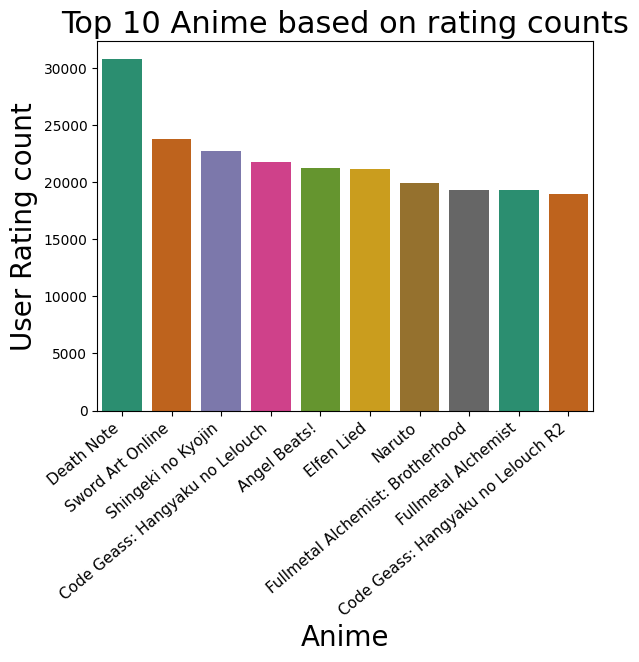

In [11]:
# Creating a dataframe for rating counts
combine_anime_rating = anime_fulldata.dropna(axis = 0, subset = ['anime_title'])
anime_ratingCount = (combine_anime_rating.
     groupby(by = ['anime_title'])['user_rating'].
     count().
     reset_index().rename(columns = {'rating': 'totalRatingCount'})
    [['anime_title', 'user_rating']]
    )


top10_animerating=anime_ratingCount[['anime_title', 'user_rating']].sort_values(by = 'user_rating',ascending = False).head(10)
ax=sns.barplot(x="anime_title", y="user_rating", data=top10_animerating, palette="Dark2")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=40, ha="right")
ax.set_title('Top 10 Anime based on rating counts',fontsize = 22)
ax.set_xlabel('Anime',fontsize = 20) 
ax.set_ylabel('User Rating count', fontsize = 20)

In [12]:
anime_fulldata = anime_fulldata.merge(anime_ratingCount, left_on = 'anime_title', right_on = 'anime_title', how = 'left')
anime_fulldata = anime_fulldata.rename(columns={'user_rating_x': 'user_rating', 'user_rating_y': 'totalratingcount'})

# Data Cleaning

In [13]:
duplicate_anime=anime_fulldata.copy()
duplicate_anime.drop_duplicates(subset ="anime_title", 
                     keep = 'first', inplace = True)

In [14]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [15]:
anime.nunique()

anime_id    12294
name        12292
genre        3264
type            6
episodes      187
rating        598
members      6706
dtype: int64

In [16]:
num_duplicates=anime.duplicated().sum()
num_duplicates

np.int64(0)

In [17]:
anime.dtypes

anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object

In [18]:
anime.isna().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [19]:
anime['genre'] = anime['genre'].fillna(anime['genre'].mode()[0])
anime['type'] = anime['type'].fillna(anime['type'].mode()[0])
anime['rating'] = anime['rating'].fillna(anime['rating'].mode()[0])

In [20]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [21]:
anime.isna().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [22]:
anime.describe()

,anime_id,rating,members
count,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,6.465036,1.807134e+04
std,11455.294701,1.019121,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.900000,2.250000e+02
50%,10260.500000,6.550000,1.550000e+03
75%,24794.500000,7.170000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [23]:
import re

def clean_text(text):
    if pd.isna(text):
        return text
    text = str(text)
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Normalize whitespace
    text = ' '.join(text.split())
    return text.strip()

anime['name'] = anime['name'].apply(clean_text)
anime['genre'] = anime['genre'].apply(clean_text)

In [24]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa,Drama Romance School Supernatural,Movie,1,9.37,200630
1,5114,Fullmetal Alchemist Brotherhood,Action Adventure Drama Fantasy Magic Military ...,TV,64,9.26,793665
2,28977,Gintama,Action Comedy Historical Parody Samurai SciFi ...,TV,51,9.25,114262
3,9253,SteinsGate,SciFi Thriller,TV,24,9.17,673572
4,9969,Gintama039,Action Comedy Historical Parody Samurai SciFi ...,TV,51,9.16,151266


In [25]:
duplicated=train.duplicated().sum()
duplicated

np.int64(1)

In [26]:
train.drop_duplicates(subset=['user_id'],keep='first',inplace=True)

In [27]:
duplicated=train.duplicated().sum()
duplicated

np.int64(0)

In [28]:
train.describe()

,user_id,anime_id,rating
count,69481.000000,69481.000000,69481.000000
mean,36772.039752,762.695586,8.474259
std,21211.298683,2742.417111,1.430355
min,1.000000,1.000000,1.000000
25%,18420.000000,15.000000,8.000000
50%,36795.000000,27.000000,9.000000
75%,55117.000000,164.000000,10.000000
max,73516.000000,34240.000000,10.000000


In [29]:
train.dtypes

user_id     int64
anime_id    int64
rating      int64
dtype: object

In [30]:
print ("The shape of the  data is (row, column):"+ str(train.shape))
print (train.info())

The shape of the  data is (row, column):(69481, 3)
<class 'pandas.core.frame.DataFrame'>
Index: 69481 entries, 0 to 5703554
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   user_id   69481 non-null  int64
 1   anime_id  69481 non-null  int64
 2   rating    69481 non-null  int64
dtypes: int64(3)
memory usage: 2.1 MB
None


In [31]:
anime_feature=anime_fulldata.copy()
anime_feature["user_rating"].replace({-1: np.nan}, inplace=True)
anime_feature.head()

,anime_id,anime_title,genre,type,episodes,rating,members,user_id,user_rating,totalratingcount
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5,1757
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10,1757
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10,1757
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10,1757
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,322,10,1757


In [32]:
anime_feature = anime_feature.dropna(axis = 0, how ='any') 
anime_feature.isnull().sum()

anime_id            0
anime_title         0
genre               0
type                0
episodes            0
rating              0
members             0
user_id             0
user_rating         0
totalratingcount    0
dtype: int64

In [33]:
anime_feature['user_id'].value_counts()

user_id
42635    3315
53698    2593
57620    2406
51693    2375
59643    2347
         ... 
61315       1
52393       1
29658       1
59256       1
13040       1
Name: count, Length: 69481, dtype: int64

#### There are users who has rated only once, even if they have rated it 5, it can't be considered a valuable record for recommendation. So I have considered minimum 200 ratings by the user as threshold value. You can play around changing the threshold value to get better results, but this worked fine.

In [34]:
counts = anime_feature['user_id'].value_counts()
anime_feature = anime_feature[anime_feature['user_id'].isin(counts[counts >= 200].index)]

### Pivot Dojo

#### This pivot table consists of rows as title and columns as user id, this will help us to create sparse matrix which can be very helpful in finding the cosine similarity ! Don't know what is cosine similarity ? don't worry, We will reveal that in the next section.

In [35]:
anime_pivot=anime_feature.pivot_table(index='anime_title',columns='user_id',values='user_rating').fillna(0)
anime_pivot.head()

user_id,5,7,17,38,43,46,123,129,139,160,...,73389,73395,73406,73417,73422,73457,73499,73502,73503,73507
anime_title,,,,,,,,,,,,,,,,,,,,,
&quot;0&quot;,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
&quot;Bungaku Shoujo&quot; Kyou no Oyatsu: Hatsukoi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0
&quot;Bungaku Shoujo&quot; Memoire,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,...,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
&quot;Bungaku Shoujo&quot; Movie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,...,7.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
&quot;Eiji&quot;,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Feature Enginnerring

In [36]:
# Extract genres into list format for later processing
anime['genre_list'] = anime['genre'].str.split(',').apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else [])

# Create popularity bins
anime['popularity'] = pd.qcut(anime['members'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

In [37]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members,genre_list,popularity
0,32281,Kimi no Na wa,Drama Romance School Supernatural,Movie,1,9.37,200630,[Drama Romance School Supernatural],Very High
1,5114,Fullmetal Alchemist Brotherhood,Action Adventure Drama Fantasy Magic Military ...,TV,64,9.26,793665,[Action Adventure Drama Fantasy Magic Military...,Very High
2,28977,Gintama,Action Comedy Historical Parody Samurai SciFi ...,TV,51,9.25,114262,[Action Comedy Historical Parody Samurai SciFi...,Very High
3,9253,SteinsGate,SciFi Thriller,TV,24,9.17,673572,[SciFi Thriller],Very High
4,9969,Gintama039,Action Comedy Historical Parody Samurai SciFi ...,TV,51,9.16,151266,[Action Comedy Historical Parody Samurai SciFi...,Very High


# Explanatory Data Analysis

In [38]:
!pip install wordcloud

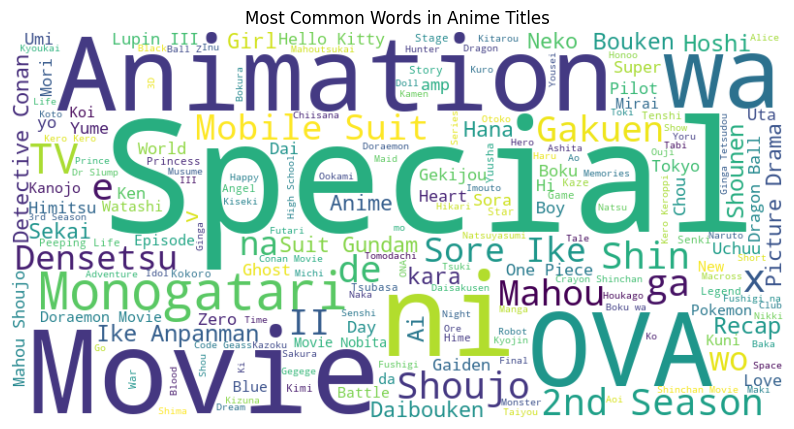

In [39]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(anime['name'].dropna()))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Anime Titles')
plt.show()

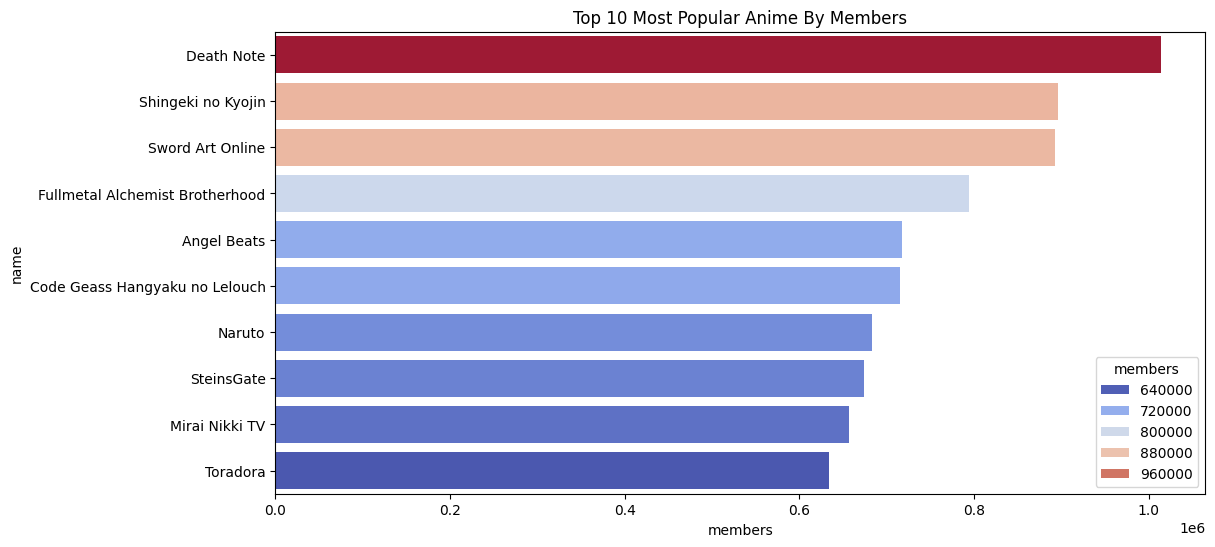

In [40]:
top_popular_anime = anime.sort_values(by='members', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_popular_anime, x='members', y='name', hue='members', palette='coolwarm')
plt.title('Top 10 Most Popular Anime By Members')
plt.show()

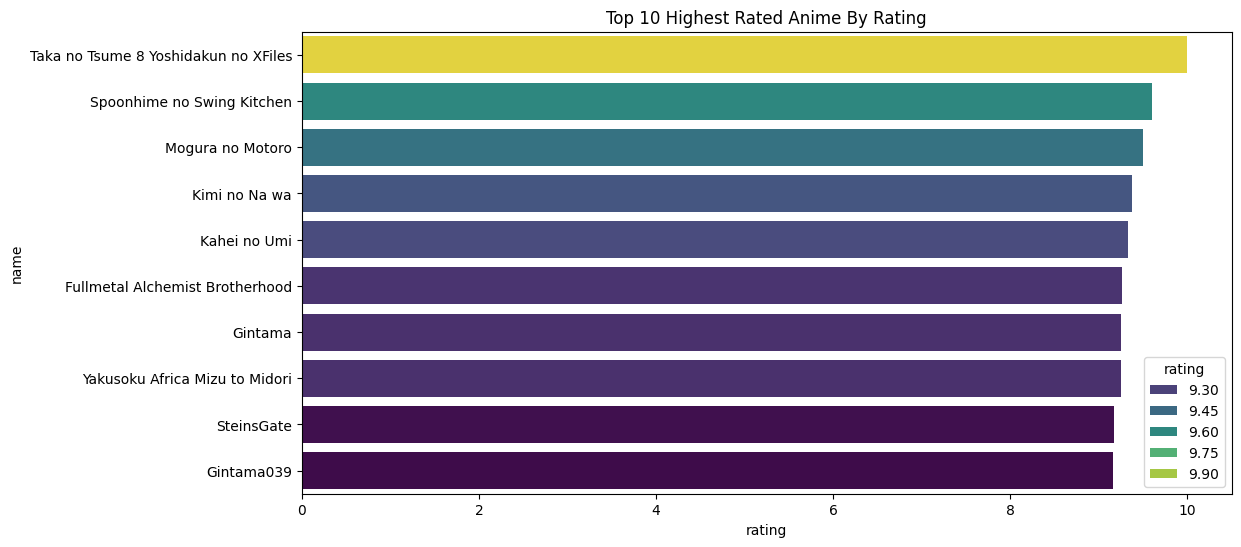

In [41]:
top_rated_anime = anime.sort_values(by='rating', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_rated_anime, x='rating', y='name', hue='rating', palette='viridis')
plt.title('Top 10 Highest Rated Anime By Rating')
plt.show()

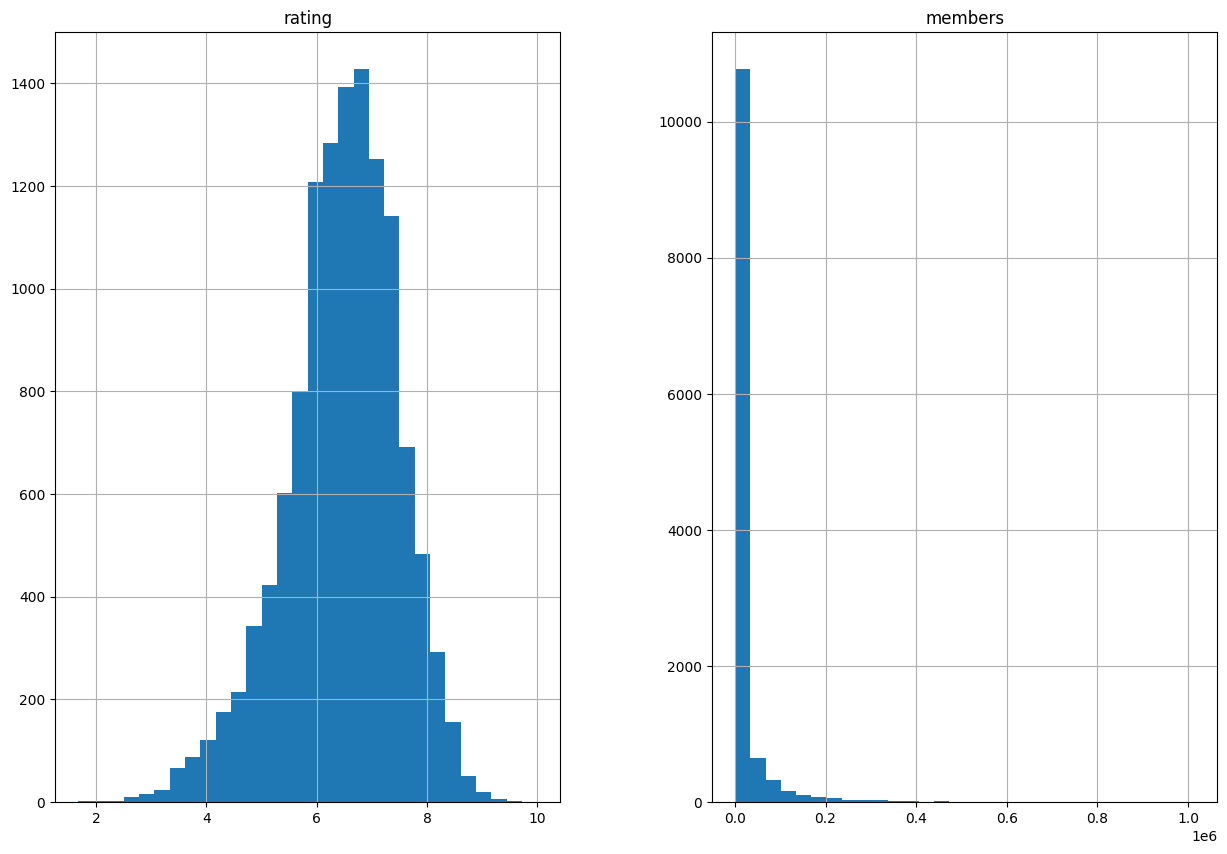

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['episodes', 'rating', 'members']
anime[num_cols].hist(bins=30, figsize=(15, 10))
plt.show()

# Categorical features
# cat_cols = ['type', 'popularity']
# for col in cat_cols:
#     plt.figure(figsize=(10, 6))
#     sns.countplot(data=anime, x=col)
#     plt.xticks(rotation=45)
#     plt.show()

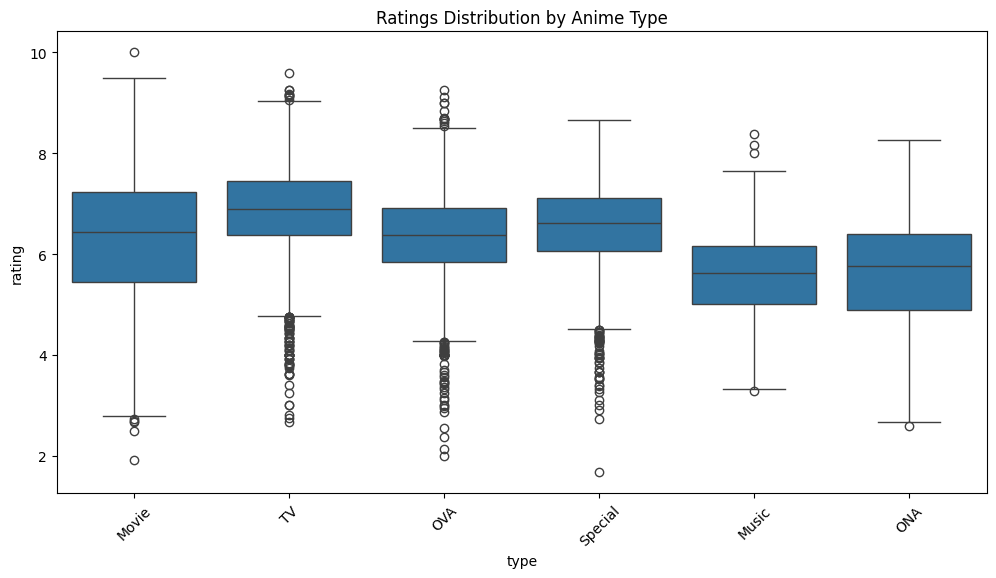

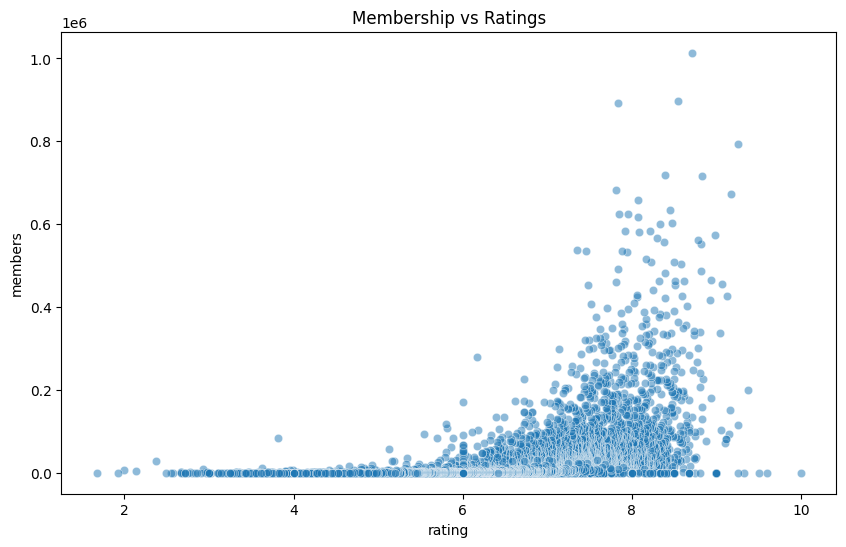

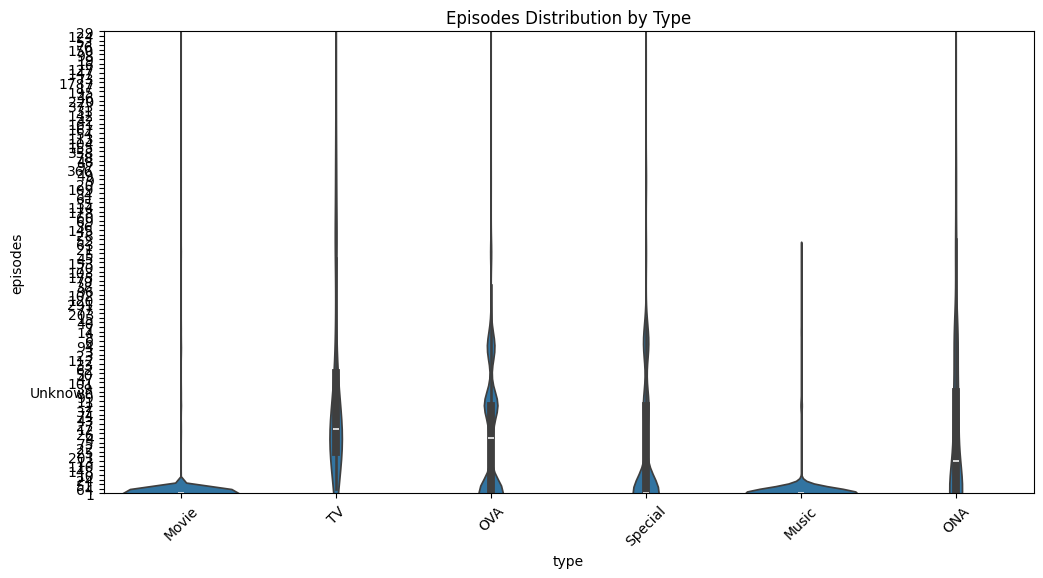

In [43]:
# Ratings vs Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=anime, x='type', y='rating')
plt.title('Ratings Distribution by Anime Type')
plt.xticks(rotation=45)
plt.show()

# Membership vs Ratings
plt.figure(figsize=(10, 6))
sns.scatterplot(data=anime, x='rating', y='members', alpha=0.5)
plt.title('Membership vs Ratings')
plt.show()

# Episodes distribution by type
plt.figure(figsize=(12, 6))
sns.violinplot(data=anime, x='type', y='episodes')
plt.ylim(0, 100)  # Limit to see most data clearly
plt.title('Episodes Distribution by Type')
plt.xticks(rotation=45)
plt.show()



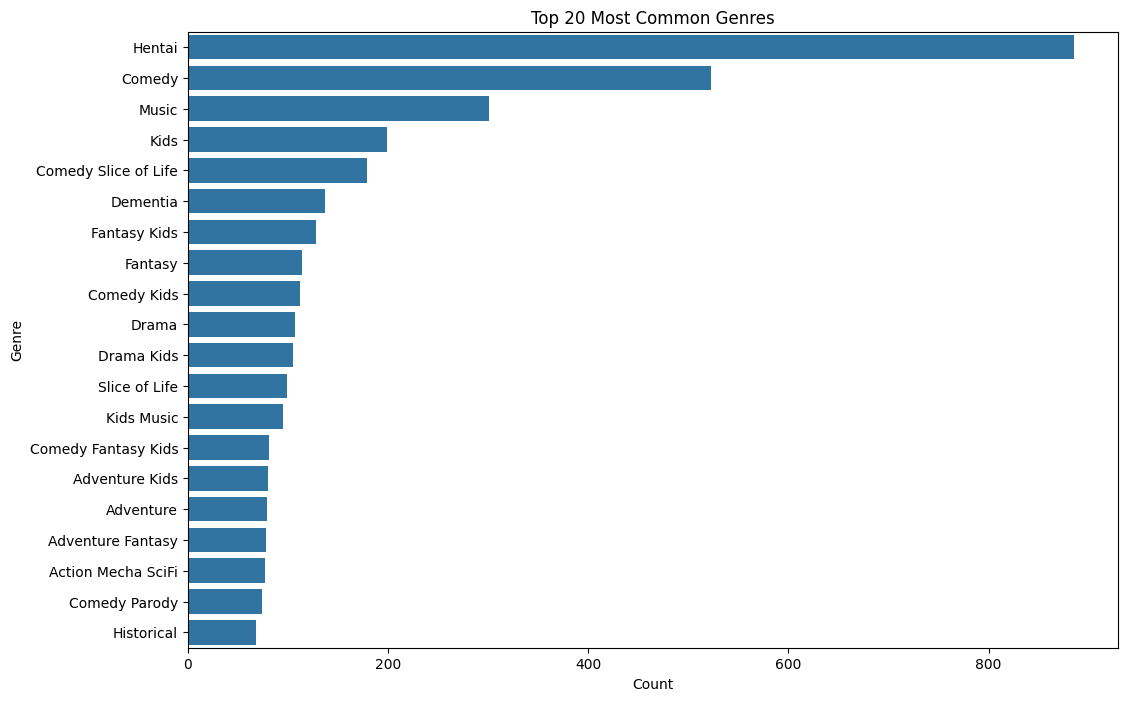

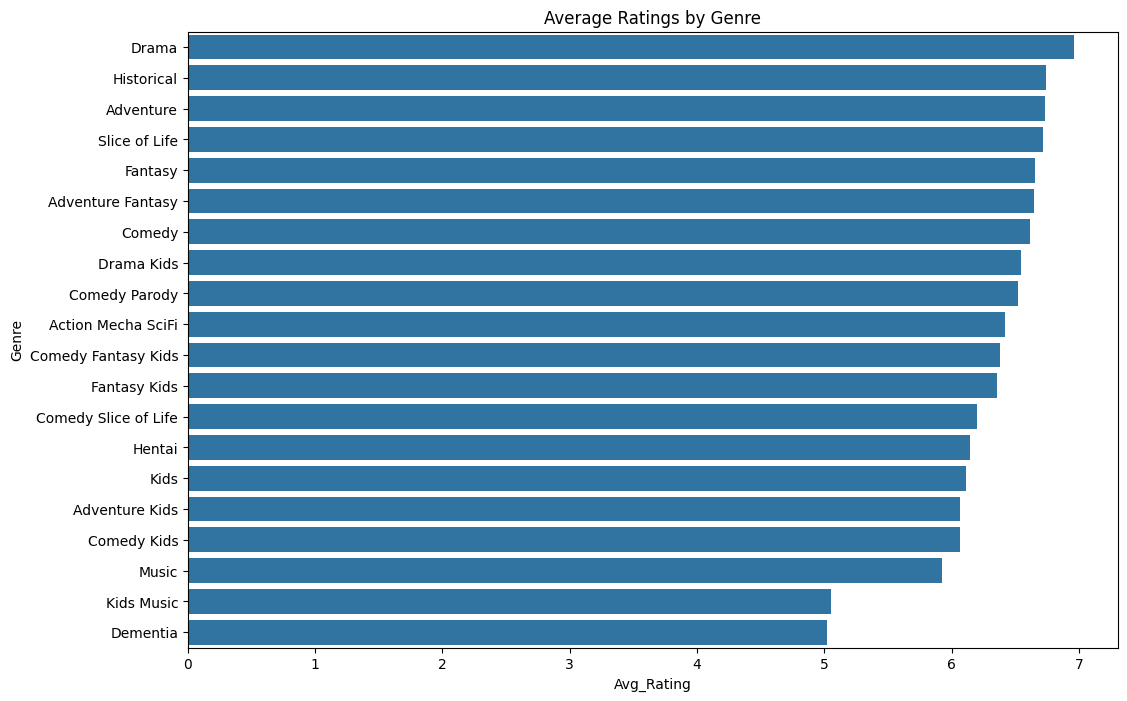

In [44]:
from collections import Counter

# Analyze genre frequency
all_genres = [genre for sublist in anime['genre_list'] for genre in sublist]
genre_counts = Counter(all_genres)

top_genres = pd.DataFrame(genre_counts.most_common(20), columns=['Genre', 'Count'])
plt.figure(figsize=(12, 8))
sns.barplot(data=top_genres, y='Genre', x='Count')
plt.title('Top 20 Most Common Genres')
plt.show()

# Genre and ratings
genre_ratings = {}
for genre in top_genres['Genre']:
    mask = anime['genre'].str.contains(genre, na=False)
    genre_ratings[genre] = anime[mask]['rating'].mean()

genre_ratings_df = pd.DataFrame(list(genre_ratings.items()), columns=['Genre', 'Avg_Rating'])
genre_ratings_df = genre_ratings_df.sort_values('Avg_Rating', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=genre_ratings_df, y='Genre', x='Avg_Rating')
plt.title('Average Ratings by Genre')
plt.show()

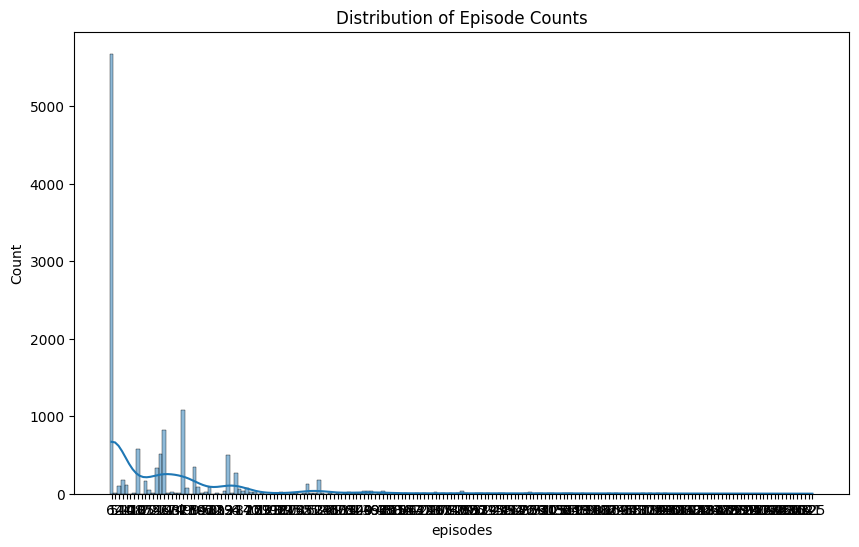

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(anime['episodes'].dropna(), bins=30, kde=True)
plt.title('Distribution of Episode Counts')
plt.show()

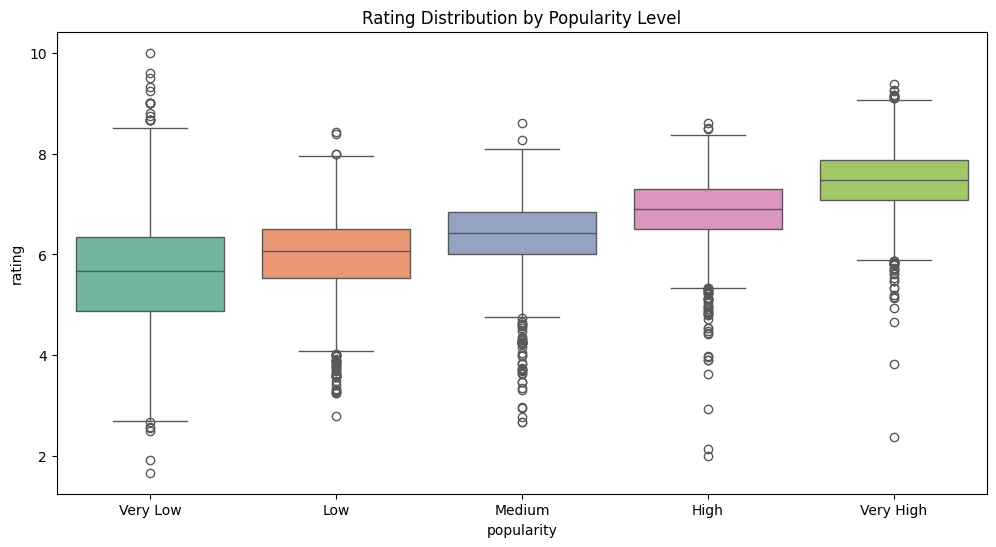

In [46]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=anime, x='popularity', y='rating', hue='popularity', palette='Set2')
plt.title('Rating Distribution by Popularity Level')
plt.show()

In [47]:
genre_rating_pivot = anime.pivot_table(index='genre', values='rating', aggfunc='mean')
print(genre_rating_pivot.sort_values('rating', ascending=False).head(10))

                                                    rating
genre                                                     
Action Adventure Drama Fantasy Magic Military S...    9.26
Drama Fantasy Romance Slice of Life Supernatural      9.06
Drama School Shounen                                  9.05
Adventure Drama Supernatural                          8.93
Drama Music Romance School Shounen                    8.92
Action Mecha Military School SciFi Super Power        8.83
Action Drama Historical Martial Arts Romance Sa...    8.83
Comedy Mystery Romance School SciFi Supernatural      8.81
Comedy Mystery Romance Supernatural Vampire           8.80
Comedy Drama School Shounen Slice of Life             8.77


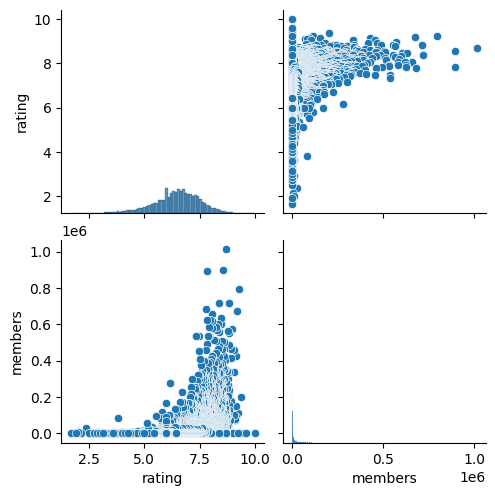

In [48]:
sns.pairplot(anime[['rating', 'members', 'episodes']])
plt.show()

# Modelling

In [49]:
# anime_feature=anime_fulldata.copy()
# anime_feature["user_rating"].replace({-1: np.nan}, inplace=True)
# anime_feature.head()

In [50]:
# stop

Collaborative filtering

In [51]:
from scipy.sparse import csr_matrix
anime_matrix = csr_matrix(anime_pivot.values)
from sklearn.neighbors import NearestNeighbors


model_knn = NearestNeighbors(metric = 'cosine', algorithm = 'brute')
model_knn.fit(anime_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [52]:
query_index = np.random.choice(anime_pivot.shape[0])
print(query_index)
distances, indices = model_knn.kneighbors(anime_pivot.iloc[query_index,:].values.reshape(1, -1), n_neighbors = 6)

920


In [53]:
for i in range(0, len(distances.flatten())):
    if i == 0:
        print('Recommendations for {0}:\n'.format(anime_pivot.index[query_index]))
    else:
        print('{0}: {1}, with distance of {2}:'.format(i, anime_pivot.index[indices.flatten()[i]], distances.flatten()[i]))

Recommendations for Blue Drop: Tenshi-tachi no Gikyoku:

1: Maria-sama ga Miteru 4th, with distance of 0.7370952742153472:
2: Kashimashi: Girl Meets Girl, with distance of 0.7377216250669684:
3: Kannazuki no Miko, with distance of 0.7402894002367246:
4: Maria-sama ga Miteru, with distance of 0.7412782353468246:
5: Maria-sama ga Miteru: Haru, with distance of 0.7449505964136864:


# Content Based Recommender

In [54]:
import re
def text_cleaning(text):
    text = re.sub(r'&quot;', '', text)
    text = re.sub(r'.hack//', '', text)
    text = re.sub(r'&#039;', '', text)
    text = re.sub(r'A&#039;s', '', text)
    text = re.sub(r'I&#039;', 'I\'', text)
    text = re.sub(r'&amp;', 'and', text)
    
    return text

anime['name'] = anime['name'].apply(text_cleaning)

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfv = TfidfVectorizer(min_df=3,  max_features=None, 
            strip_accents='unicode', analyzer='word',token_pattern=r'\w{1,}',
            ngram_range=(1, 3),
            stop_words = 'english')

# Filling NaNs with empty string
anime['genre'] = anime['genre'].fillna('')
genres_str = anime['genre'].str.split(',').astype(str)
tfv_matrix = tfv.fit_transform(genres_str)

In [56]:
tfv_matrix.shape

(12294, 1585)

In [57]:
from sklearn.metrics.pairwise import sigmoid_kernel

# Compute the sigmoid kernel
sig = sigmoid_kernel(tfv_matrix, tfv_matrix)

In [58]:
indices = pd.Series(anime.index, index=anime['name']).drop_duplicates()

# Reccomendations

In [59]:
def give_rec(title, sig=sig):
    # Get the index corresponding to original_title
    idx = indices[title]

    # Get the pairwsie similarity scores 
    sig_scores = list(enumerate(sig[idx]))

    # Sort the movies 
    sig_scores = sorted(sig_scores, key=lambda x: x[1], reverse=True)

    # Scores of the 10 most similar movies
    sig_scores = sig_scores[1:11]

    # Movie indices
    anime_indices = [i[0] for i in sig_scores]

    # Top 10 most similar movies
    return pd.DataFrame({'Anime name': anime['name'].iloc[anime_indices].values,
                                 'Rating': anime['rating'].iloc[anime_indices].values})

In [60]:
give_rec('Death Note')

,Anime name,Rating
0,Death Note Rewrite,7.84
1,Mousou Dairinin,7.74
2,Higurashi no Naku Koro ni Kai,8.41
3,Higurashi no Naku Koro ni Rei,7.56
4,Bloody Night,4.26
5,Higurashi no Naku Koro ni,8.17
6,Shigofumi,7.62
7,Himitsu The Revelation,7.42
8,Hikari to Mizu no Daphne,6.87
9,Monster,8.72


In [61]:
give_rec('Kimi no Na wa')

,Anime name,Rating
0,Wind A Breath of Heart OVA,6.35
1,Wind A Breath of Heart TV,6.14
2,Aura Maryuuin Kouga Saigo no Tatakai,7.67
3,Kokoro ga Sakebitagatterunda,8.32
4,Clannad After Story Mou Hitotsu no Sekai Kyouhen,8.02
5,True Tears,7.55
6,quotBungaku Shoujoquot Memoire,7.54
7,Kimikiss Pure Rouge,7.48
8,Myself Yourself,7.41
9,Koi to Senkyo to Chocolate,7.30


In [62]:
give_rec('Shingeki no Kyojin')

,Anime name,Rating
0,Shingeki no Kyojin OVA,7.88
1,Shingeki no Kyojin Movie 2 Jiyuu no Tsubasa,7.75
2,Shingeki no Kyojin Movie 1 Guren no Yumiya,7.70
3,Shingeki no Kyojin Ano Hi Kara,6.96
4,Shingeki no Kyojin Season 2,6.00
5,One Piece,8.58
6,One Piece Episode of Merry Mou Hitori no Nakam...,8.29
7,One Piece Episode of Nami Koukaishi no Namida ...,8.27
8,One Piece Episode of Sabo 3 Kyoudai no Kizuna ...,7.78
9,Dragon Ball Specials,6.96


In [63]:
give_rec('One Piece')

,Anime name,Rating
0,One Piece Episode of Merry Mou Hitori no Nakam...,8.29
1,One Piece Episode of Nami Koukaishi no Namida ...,8.27
2,One Piece Episode of Sabo 3 Kyoudai no Kizuna ...,7.78
3,One Piece Film Strong World,8.42
4,One Piece Film Z,8.39
5,One Piece Film Gold,8.32
6,One Piece Heart of Gold,7.75
7,Digimon Frontier,7.25
8,Digimon Tamers,7.65
9,Digimon Savers,7.10


# Rating predictions

In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import sigmoid_kernel
import re
import mlflow
import pickle

# --- Collaborative Filtering ---

# def collaborative_filtering_model(anime_pivot, query_index=None, n_neighbors=6):
#     """
#     Trains a KNN model for collaborative filtering and returns recommendations.

#     Args:
#         anime_pivot (pd.DataFrame): Pivot table of anime ratings.
#         query_index (int, optional): Index of the query anime. Defaults to a random index.
#         n_neighbors (int, optional): Number of neighbors for KNN. Defaults to 6.

#     Returns:
#         pd.DataFrame: Recommendations for the query anime.
#     """
#     anime_matrix = csr_matrix(anime_pivot.values)
#     model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
#     model_knn.fit(anime_matrix)

#     if query_index is None:
#         query_index = np.random.choice(anime_pivot.shape[0])

#     distances, indices = model_knn.kneighbors(anime_pivot.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n_neighbors)

#     recommendations = []
#     for i in range(1, len(distances.flatten())):  # Start from 1 to exclude the query anime itself
#         recommendations.append({
#             'Anime name': anime_pivot.index[indices.flatten()[i]],
#             'Distance': distances.flatten()[i]
#         })

#     return pd.DataFrame(recommendations) , model_knn, query_index

def collaborative_filtering_model(anime_pivot, anime_pivot_sparse = None, query_index=None, n_neighbors=6):
    """
    Trains a KNN model for collaborative filtering and returns recommendations.

    Args:
        anime_pivot (pd.DataFrame): Pivot table of anime ratings.
        query_index (int, optional): Index of the query anime. Defaults to a random index.
        n_neighbors (int, optional): Number of neighbors for KNN. Defaults to 6.

    Returns:
        pd.DataFrame: Recommendations for the query anime.
    """
    if anime_pivot_sparse is None :
        anime_matrix = csr_matrix(anime_pivot.values)
    else :
        anime_matrix = anime_pivot_sparse

    model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
    model_knn.fit(anime_matrix)

    if query_index is None:
        query_index = np.random.choice(anime_pivot.shape[0])

    distances, indices = model_knn.kneighbors(anime_pivot.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n_neighbors)

    recommendations = []
    for i in range(1, len(distances.flatten())):  # Start from 1 to exclude the query anime itself
        recommendations.append({
            'Anime name': anime_pivot.index[indices.flatten()[i]],
            'Distance': distances.flatten()[i]
        })

    return pd.DataFrame(recommendations) , model_knn, query_index

# --- Content-Based Filtering ---

def text_cleaning(text):
    """Cleans text data for genre description."""
    text = re.sub(r'&quot;', '', text)
    text = re.sub(r'.hack//', '', text)
    text = re.sub(r'&#039;', '', text)
    text = re.sub(r'A&#039;s', '', text)
    text = re.sub(r'I&#039;', 'I\'', text)
    text = re.sub(r'&amp;', 'and', text)
    return text

def content_based_model(anime, title, n_recommendations=10):
    """
    Trains a TF-IDF based content-based filtering model and returns recommendations.

    Args:
        anime (pd.DataFrame): DataFrame containing anime data with genre information.
        title (str): Title of the anime to get recommendations for.
        n_recommendations (int, optional): Number of recommendations to return. Defaults to 10.

    Returns:
        pd.DataFrame: Top N recommendations based on genre similarity.
    """
    anime['name'] = anime['name'].apply(text_cleaning)
    anime['genre'] = anime['genre'].fillna('')
    genres_str = anime['genre'].str.split(',').astype(str)

    tfv = TfidfVectorizer(min_df=3, max_features=None, strip_accents='unicode', analyzer='word',
                          token_pattern=r'\w{1,}', ngram_range=(1, 3), stop_words='english')
    tfv_matrix = tfv.fit_transform(genres_str)
    sig = sigmoid_kernel(tfv_matrix, tfv_matrix)
    indices = pd.Series(anime.index, index=anime['name']).drop_duplicates()

    def give_rec(title, sig=sig):
        idx = indices[title]
        sig_scores = list(enumerate(sig[idx]))
        sig_scores = sorted(sig_scores, key=lambda x: x[1], reverse=True)
        sig_scores = sig_scores[1:n_recommendations + 1]
        anime_indices = [i[0] for i in sig_scores]
        return pd.DataFrame({'Anime name': anime['name'].iloc[anime_indices].values,
                             'Rating': anime['rating'].iloc[anime_indices].values})
    
    return give_rec(title), tfv, sig, indices

# --- MLflow and Pickle Implementation ---

def save_models_and_data(anime_pivot, anime, collaborative_model, content_model, tfv, sig, indices, query_index):
    """Saves models, data, and parameters using MLflow and pickle."""

    with mlflow.start_run():
        # Log parameters
        mlflow.log_param("collaborative_model_type", "KNN")
        mlflow.log_param("content_model_type", "TF-IDF + Sigmoid Kernel")
        mlflow.log_param("collaborative_query_index", query_index)

        # Save models as pickle files
        with open("collaborative_model.pkl", "wb") as f:
            pickle.dump(collaborative_model, f)
        mlflow.log_artifact("collaborative_model.pkl")

        with open("content_model_tfv.pkl", "wb") as f:
            pickle.dump(tfv, f)
        mlflow.log_artifact("content_model_tfv.pkl")

        with open("content_model_sig.pkl", "wb") as f:
            pickle.dump(sig, f)
        mlflow.log_artifact("content_model_sig.pkl")

        with open("content_model_indices.pkl", "wb") as f:
            pickle.dump(indices, f)
        mlflow.log_artifact("content_model_indices.pkl")

        # Save dataframes as pickle files
        with open("anime_pivot.pkl", "wb") as f:
            pickle.dump(anime_pivot, f)
        mlflow.log_artifact("anime_pivot.pkl")

        with open("anime.pkl", "wb") as f:
            pickle.dump(anime, f)
        mlflow.log_artifact("anime.pkl")

In [69]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import sigmoid_kernel
import re
import mlflow
import pickle

# Load data
anime = pd.read_csv("anime.csv")
rating = pd.read_csv("train.csv")
anime_rating = pd.merge(anime, rating, on='anime_id', suffixes=['', '_user'])
anime_rating = anime_rating[anime_rating['rating_user'] != -1]

# More aggressive filtering
top_n_users = 1000  # Adjust as needed
top_m_anime = 2000  # Adjust as needed

user_ratings_count = anime_rating['user_id'].value_counts()
top_users = user_ratings_count.nlargest(top_n_users).index
anime_ratings_count = anime_rating['name'].value_counts()
top_anime = anime_ratings_count.nlargest(top_m_anime).index

anime_rating_filtered = anime_rating[
    (anime_rating['user_id'].isin(top_users)) & (anime_rating['name'].isin(top_anime))
]

# Create sparse pivot table
anime_pivot = anime_rating_filtered.pivot_table(index='name', columns='user_id', values='rating_user')
anime_pivot_sparse = csr_matrix(anime_pivot.fillna(0))

# Train collaborative filtering model
collaborative_recs, collaborative_model, query_index = collaborative_filtering_model(anime_pivot, anime_pivot_sparse = anime_pivot_sparse)

# Train content-based filtering model
content_recs, tfv, sig, indices = content_based_model(anime, 'Death Note')

# Save models and data
save_models_and_data(anime_pivot, anime, collaborative_model, tfv, sig, indices, query_index)

print("Collaborative Recommendations:")
print(collaborative_recs)

print("\nContent-Based Recommendations:")
print(content_recs)

MemoryError: Unable to allocate 87.0 MiB for an array with shape (2, 5703553) and data type int64